<a href="https://colab.research.google.com/github/Rasheena-Arimbrathodi/Datasets/blob/main/ama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import requests
import pandas as pd
import multiprocessing
import time
from time import time as timer
from tqdm import tqdm
import numpy as np
from pathlib import Path
from functools import partial
import urllib
from PIL import Image
import re

# Define allowed units for parsing
allowed_units = {
    'centimetre', 'foot', 'inch', 'metre', 'millimetre', 'yard', 'gram', 'kilogram',
    'microgram', 'milligram', 'ounce', 'pound', 'ton', 'kilovolt', 'millivolt',
    'volt', 'kilowatt', 'watt', 'centilitre', 'cubic foot', 'cubic inch', 'cup',
    'decilitre', 'fluid ounce', 'gallon', 'imperial gallon', 'litre', 'microlitre',
    'millilitre', 'pint', 'quart'
}

# Fixing the common_mistake function to handle common mistakes in units
def common_mistake(unit):
    if unit in allowed_units:
        return unit
    if unit.replace('ter', 'tre') in allowed_units:
        return unit.replace('ter', 'tre')
    if unit.replace('feet', 'foot') in allowed_units:
        return unit.replace('feet', 'foot')
    return unit

# Parsing string to extract numerical values and units
def parse_string(s):
    s_stripped = "" if s is None or str(s) == 'nan' else s.strip()
    if s_stripped == "":
        return None, None
    pattern = re.compile(r'^-?\d+(\.\d+)?\s+[a-zA-Z\s]+$')
    if not pattern.match(s_stripped):
        raise ValueError("Invalid format in {}".format(s))
    parts = s_stripped.split(maxsplit=1)
    number = float(parts[0])
    unit = common_mistake(parts[1])

    if unit not in allowed_units:
        raise ValueError(f"Invalid unit [{unit}] found in {s}. Allowed units: {allowed_units}")
    return number, unit

# Placeholder image creation
def create_placeholder_image(image_save_path):
    try:
        placeholder_image = Image.new('RGB', (100, 100), color='black')
        placeholder_image.save(image_save_path)
        print(f"Placeholder image created at: {image_save_path}")
    except Exception as e:
        print(f"Error creating placeholder image: {e}")
        return

# Function to download images from a CSV dataset and store them
def process_dataset_and_download_images(csv_file_path, download_folder):
    # Load the dataset
    df = pd.read_csv(csv_file_path)

    # Extract the image links column
    image_links = df['image_link'].tolist()

    # Download the images from the extracted URLs
    download_images(image_links, download_folder, allow_multiprocessing=True)

# Function to download an image from URL
def download_image(image_link, save_folder, retries=3, delay=3):
    if not isinstance(image_link, str):
        return
    filename = Path(image_link).name
    image_save_path = os.path.join(save_folder, filename)
    if os.path.exists(image_save_path):
        print(f"Image already exists: {image_save_path}")
        return
    for _ in range(retries):
        try:
            urllib.request.urlretrieve(image_link, image_save_path)
            print(f"Downloaded image: {image_save_path}")
            return
        except:
            time.sleep(delay)

    create_placeholder_image(image_save_path)  # Create a black placeholder image for invalid links/images

# Multiprocessing function to download images in parallel
def download_images(image_links, download_folder, allow_multiprocessing=True):
    if not os.path.exists(download_folder):
        os.makedirs(download_folder)
    if allow_multiprocessing:
        download_image_partial = partial(download_image, save_folder=download_folder, retries=3, delay=3)
        with multiprocessing.Pool(64) as pool:
            list(tqdm(pool.imap(download_image_partial, image_links), total=len(image_links)))
            pool.close()
            pool.join()
    else:
        for image_link in tqdm(image_links, total=len(image_links)):
            download_image(image_link, save_folder=download_folder, retries=3, delay=3)

# Example image URL to download from m.media-amazon
image_link = 'https://m.media-amazon.com/images/I/71XfHPR36-L.jpg'  # Example image URL
save_folder = '/content/sample_data'  # Folder path to save images in Google Colab

# Ensure the folder exists
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

# Call the function to download the image
download_image(image_link, save_folder)

# If you have a CSV with image links, specify its path and call the process function
# csv_file_path = '/path/to/your/csv_file.csv'  # Update this with your actual CSV path
# download_folder = '/content/sample_data'  # Folder path in Google Colab to save images
# process_dataset_and_download_images(csv_file_path, download_folder)


Downloaded image: /content/sample_data/71XfHPR36-L.jpg


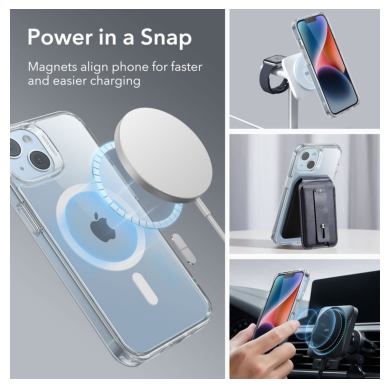

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
# Open and show the image
img = Image.open('/content/sample_data/71XfHPR36-L.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
!apt-get install tesseract-ocr
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (5,900 kB/s)
Selecting previously unselected package tesseract-ocr-eng.
(Reading database ... 123597 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-

In [ ]:
import pytesseract

# Extract text from the image
extracted_text = pytesseract.image_to_string(img)
print(extracted_text)


Power in a Snap

Magnets align phone for faster
and easier charging

 



In [ ]:
import re

# Example of regex to extract float + unit pattern
pattern = r'(\d+(\.\d+)?\s*(cm|kg|gram|litre|inch|foot))'
matches = re.findall(pattern, extracted_text)

# If matches found, return the first one
if matches:
    entity_value = matches[0][0]  # Get the first matched value
else:
    entity_value = ""  # No entity found

print(f"Extracted entity: {entity_value}")


Extracted entity: 


In [ ]:
import pandas as pd

# Prepare the result as a DataFrame
df_output = pd.DataFrame({
    'index': [1],  # Assuming index is 1 for this single image
    'prediction': [entity_value]  # Use the extracted entity value
})

# Save the output as a CSV file
output_csv = '/content/sample_data/output.csv'
df_output.to_csv(output_csv, index=False)
print(f"Result saved to {output_csv}")


Result saved to /content/sample_data/output.csv


In [ ]:
!sudo apt-get install tesseract-ocr
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv('/content/sample_data/output.csv')

# Add the prediction (extracted text) to the CSV
df.loc[df['index'] == 1, 'prediction'] = extracted_text

# Save the updated CSV
df.to_csv('updated_predictions.csv', index=False)


<ipython-input-12-d260a4cd8627>:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Power in a Snap

Magnets align phone for faster
and easier charging

 
' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['index'] == 1, 'prediction'] = extracted_text
